In [1]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

data = pd.read_csv("horse_colic_normalized.csv", delimiter=",")

df_reduced = pd.read_csv(
    "horse_colic_reduced_encoded.csv",
    delimiter=","
)

target_col = "outcome"

data = data.dropna(subset=[target_col])
df_reduced = df_reduced.dropna(subset=[target_col])

display(data.head())
display(df_reduced.head())

,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2


,surgery,hospital_number,rectal_temperature,pulse,respiratory_rate,mucous_membranes,pain,peristalsis,abdominal_distension,abdomen,packed_cell_volume,total_protein,outcome,lesion_site,surgical_lesion
0,2.0,530101,38.5,66.0,28.0,NaN,5.0,4.0,4.0,5.0,45.0,8.4,2.0,11300,2
1,1.0,534817,39.2,88.0,20.0,4.0,3.0,4.0,2.0,2.0,50.0,85.0,3.0,2208,2
2,2.0,530334,38.3,40.0,24.0,3.0,3.0,3.0,1.0,1.0,33.0,6.7,1.0,0,2
3,1.0,5290409,39.1,164.0,84.0,6.0,2.0,4.0,4.0,NaN,48.0,7.2,2.0,2208,1
4,2.0,530255,37.3,104.0,35.0,6.0,NaN,NaN,NaN,NaN,74.0,7.4,2.0,4300,2


In [2]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=[target_col])
y = data[target_col]

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

boosting_model = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    random_state=42
)

boosting_model.fit(X_train, y_train)

y_pred = boosting_model.predict(X_test)
y_prob = boosting_model.predict_proba(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, zero_division=0))


X_reduced = df_reduced.drop(columns=[target_col])
y_reduced = df_reduced[target_col]

X_reduced = X_reduced.fillna(X_reduced.median())

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

boosting_model_reduced = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    random_state=42
)

boosting_model_reduced.fit(X_train_reduced, y_train_reduced)

y_pred_reduced = boosting_model_reduced.predict(X_test_reduced)
y_prob_reduced = boosting_model_reduced.predict_proba(X_test_reduced)

print('Accuracy reduced:', accuracy_score(y_test_reduced, y_pred_reduced))
print('\nClassification report reduced:')
print(classification_report(y_test_reduced, y_pred_reduced, zero_division=0))

Accuracy: 0.6891891891891891

Classification report:
              precision    recall  f1-score   support

         1.0       0.80      0.78      0.79        45
         2.0       0.52      0.67      0.59        18
         3.0       0.57      0.36      0.44        11

    accuracy                           0.69        74
   macro avg       0.63      0.60      0.61        74
weighted avg       0.70      0.69      0.69        74

Accuracy reduced: 0.7162162162162162

Classification report reduced:
              precision    recall  f1-score   support

         1.0       0.82      0.80      0.81        45
         2.0       0.57      0.72      0.63        18
         3.0       0.57      0.36      0.44        11

    accuracy                           0.72        74
   macro avg       0.65      0.63      0.63        74
weighted avg       0.72      0.72      0.71        74



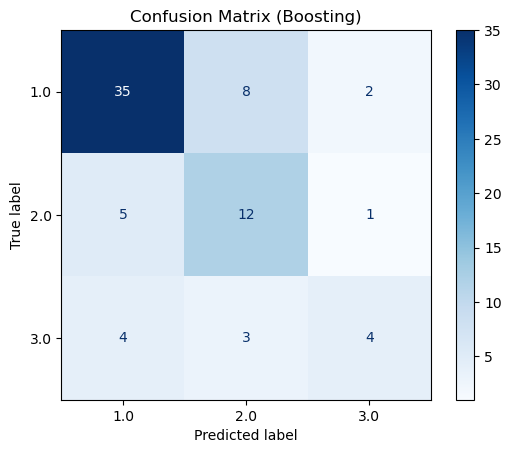

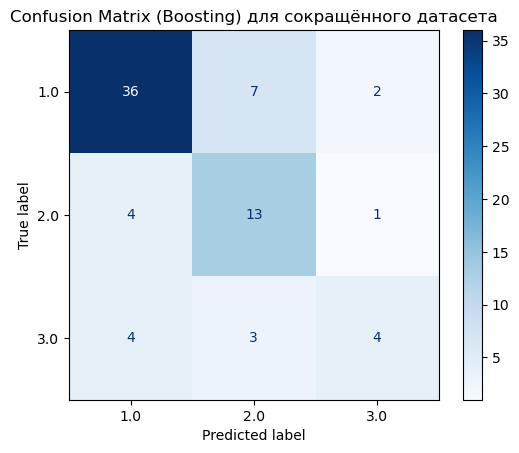

In [3]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=boosting_model.classes_
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Boosting)')
plt.grid(False)
plt.show()


cm_reduced = confusion_matrix(y_test_reduced, y_pred_reduced)

disp_reduced = ConfusionMatrixDisplay(
    confusion_matrix=cm_reduced,
    display_labels=boosting_model_reduced.classes_
)

disp_reduced.plot(cmap='Blues')
plt.title('Confusion Matrix (Boosting) для сокращённого датасета')
plt.grid(False)
plt.show()

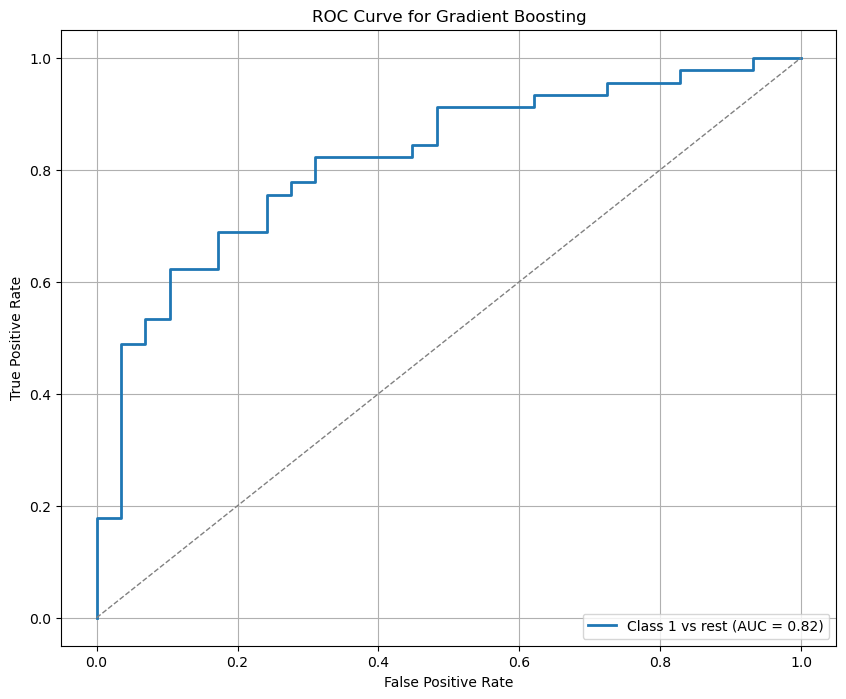

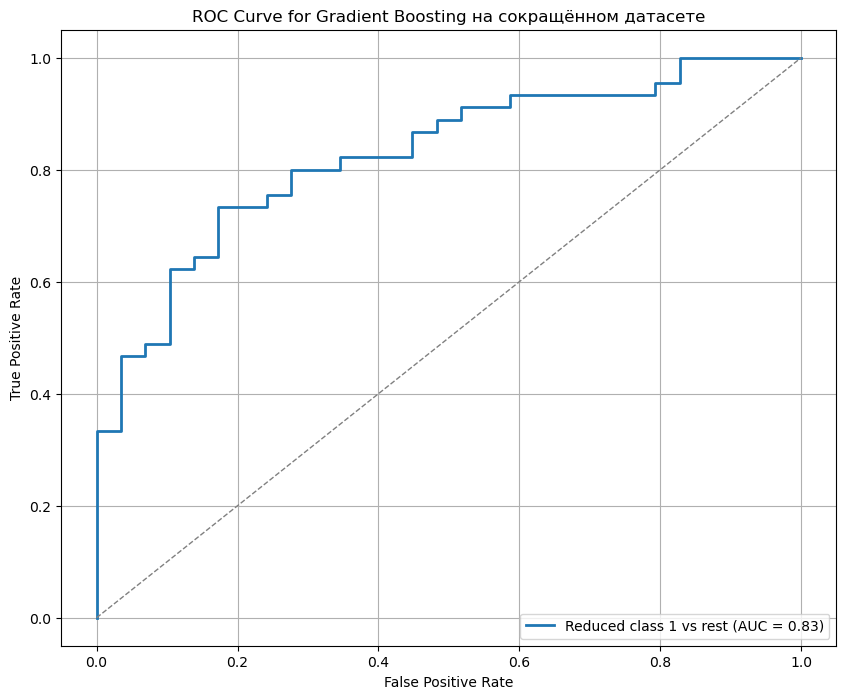

In [4]:
positive_class = 1

y_test_binary = (y_test == positive_class).astype(int)

positive_class_index = list(boosting_model.classes_).index(positive_class)

y_score = y_prob[:, positive_class_index]

fpr, tpr, _ = roc_curve(
    y_test_binary,
    y_score
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'Class {positive_class} vs rest (AUC = {roc_auc:.2f})'
)

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve for Gradient Boosting')

plt.legend(loc='lower right')
plt.grid()
plt.show()


positive_class_reduced = 1

y_test_reduced_binary = (
    y_test_reduced == positive_class_reduced
).astype(int)

positive_class_index_reduced = list(
    boosting_model_reduced.classes_
).index(positive_class_reduced)

y_score_reduced = y_prob_reduced[
    :,
    positive_class_index_reduced
]

fpr_reduced, tpr_reduced, _ = roc_curve(
    y_test_reduced_binary,
    y_score_reduced
)

roc_auc_reduced = auc(
    fpr_reduced,
    tpr_reduced
)

plt.figure(figsize=(10, 8))

plt.plot(
    fpr_reduced,
    tpr_reduced,
    lw=2,
    label=f'Reduced class {positive_class_reduced} vs rest (AUC = {roc_auc_reduced:.2f})'
)

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve for Gradient Boosting на сокращённом датасете')

plt.legend(loc='lower right')
plt.grid()
plt.show()